### Importing the cleaned data set

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

df = pd.read_csv("netflix_cleaned.csv")

df.head()


,show_id,title,director,cast,release_year,duration,description,duration_int,duration_type,is_movie,...,tv action & adventure,tv comedies,tv dramas,tv horror,tv mysteries,tv sci-fi & fantasy,tv shows,tv thrillers,rating_encoded,country_encoded
0,s1,Dick Johnson Is Dead,Kirsten Johnson,Unknown,2020,90 min,"As her father nears the end of his life, filmm...",90,min,1,...,0,0,0,0,0,0,0,0,5,603
1,s2,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",2021,2 Seasons,"After crossing paths at a party, a Cape Town t...",2,Seasons,0,...,0,0,1,0,1,0,0,0,9,426
2,s3,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",2021,1 Season,To protect his family from a powerful drug lor...,1,Season,0,...,1,0,0,0,0,0,0,0,9,736
3,s4,Jailbirds New Orleans,Unknown,Unknown,2021,1 Season,"Feuds, flirtations and toilet talk go down amo...",1,Season,0,...,0,0,0,0,0,0,0,0,9,736
4,s5,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",2021,2 Seasons,In a city of coaching centers known to train I...,2,Seasons,0,...,0,1,0,0,0,0,0,0,9,251


### Univariant analysis

### 1. Content Type Distribution (Movies vs TV Shows)

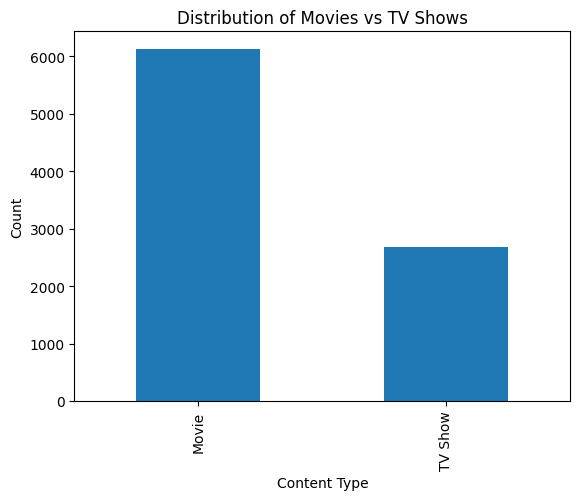

In [20]:
plt.figure()

df['is_movie'].value_counts().rename({
    1: "Movie",
    0: "TV Show"
}).plot(kind='bar')

plt.title("Distribution of Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

 Netflix focuses more on movie content volume.

### 2. Release Year Trend

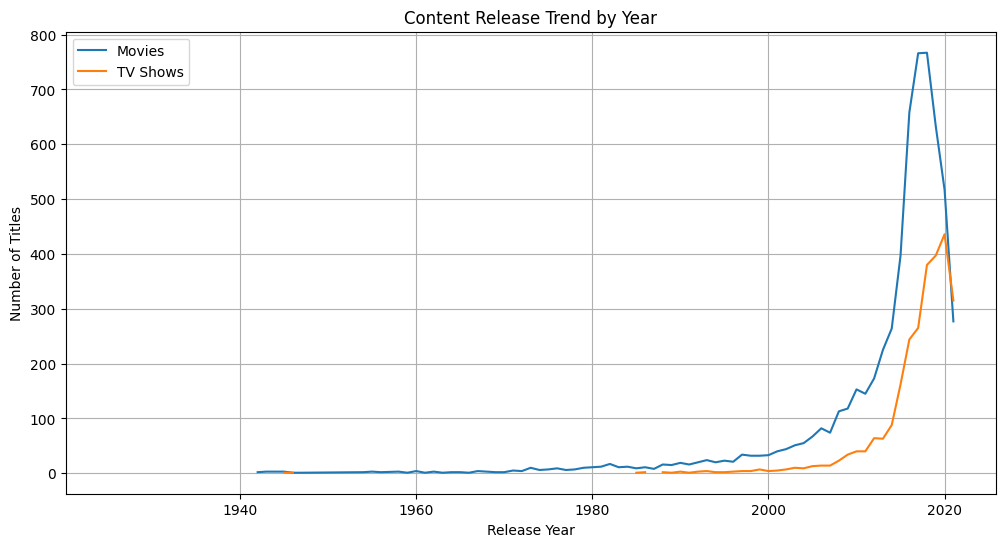

In [21]:
# Ensure release_year is numeric
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')

# Create grouped data
yearly_trend = (
    df.groupby(['release_year', 'is_movie'])
      .size()
      .unstack()
)

# Rename columns safely (works for 0/1 )
yearly_trend = yearly_trend.rename(columns={
    1: "Movie",
    0: "TV Show",
})

# Sort by year
yearly_trend = yearly_trend.sort_index()

# Plot
plt.figure(figsize=(12,6))

if "Movie" in yearly_trend.columns:
    plt.plot(yearly_trend.index, yearly_trend["Movie"], label="Movies")

if "TV Show" in yearly_trend.columns:
    plt.plot(yearly_trend.index, yearly_trend["TV Show"], label="TV Shows")

plt.title("Content Release Trend by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend()
plt.grid(True)

plt.show()

Netflix primarily features content that was released in the early 2000s. The platform experienced a significant increase in content additions between 2015 and 2020, reaching its peak in 2019 and 2020. During this period, the number of TV series also increased considerably.

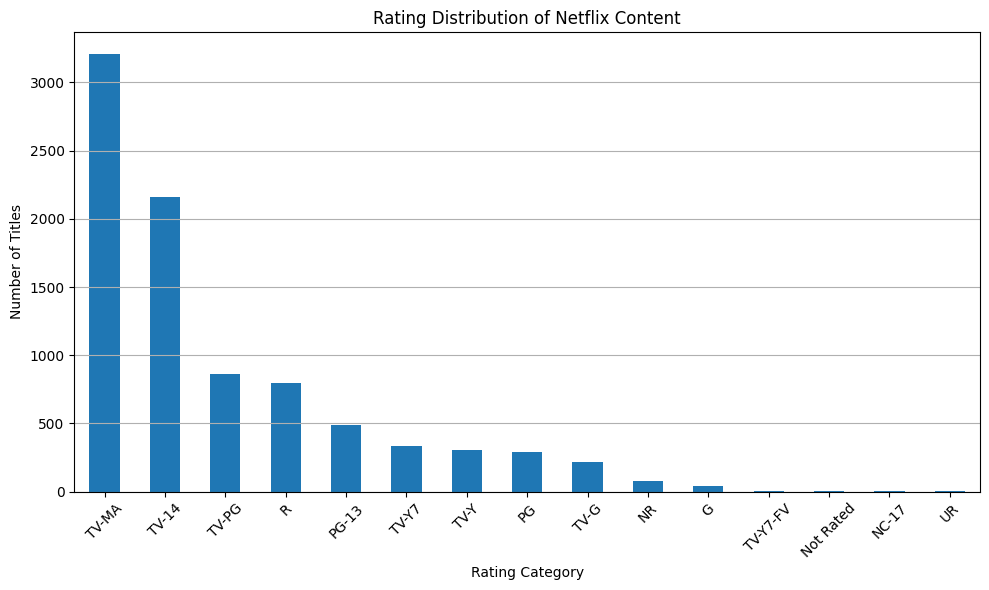

In [22]:

with open(r"C:\Users\rohit\projects\Infosys Internship\Netflix Content Strategy Analyzer Insights into Global Streaming Trends\encoding_mappings.json", "r") as f:
    encoding_map = json.load(f)

rating_mapping = encoding_map["rating_mapping"]
reverse_rating_map = {v: k for k, v in rating_mapping.items()}
df['rating_label'] = df['rating_encoded'].map(reverse_rating_map)
df = df.dropna(subset=['rating_label'])

rating_counts = df['rating_label'].value_counts()

plt.figure(figsize=(10,6))

rating_counts.plot(kind='bar')

plt.title("Rating Distribution of Netflix Content")
plt.xlabel("Rating Category")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

The majority of Netflix content falls under TV-MA, showing a strong focus on mature and adult audiences.

TV-14 is the second most common rating, indicating a significant amount of content suitable for teenagers and young adults.

Ratings like TV-PG and PG-13 have moderate representation, showing that some family-friendly content is available.

Kids-only categories such as TV-Y, TV-G, and G have comparatively fewer titles.

Very few titles are marked as Not Rated or similar categories, meaning most content is properly classified.

Overall, Netflix mainly targets adult and young adult viewers rather than focusing primarily on children or family audiences.

### 4. Duration Distribution (movies and tv series)

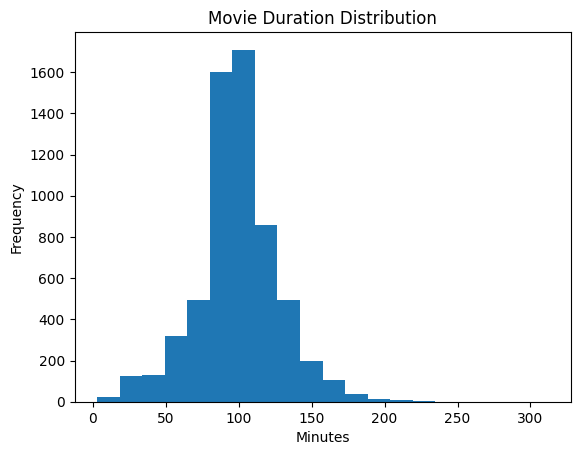

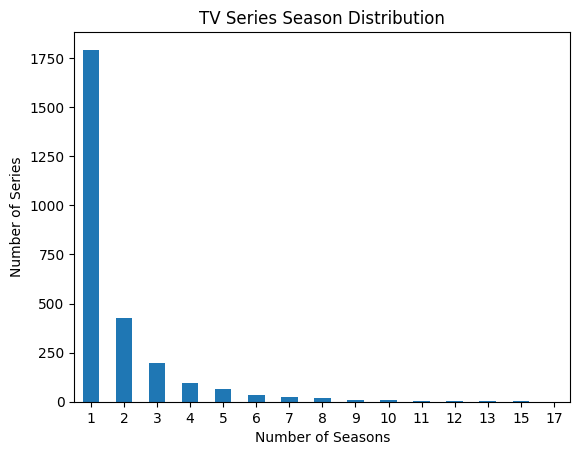

In [23]:

movies = df[df['is_movie'] == 1].copy()
series = df[df['is_movie'] == 0].copy()

movies['duration'] = movies['duration'].str.replace(" min", "", regex=False)
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

series['duration'] = series['duration'].str.replace(" Season", "", regex=False)
series['duration'] = series['duration'].str.replace(" Seasons", "", regex=False)
series['duration'] = pd.to_numeric(series['duration'], errors='coerce')

# Plot Movie Duration Distribution
plt.figure()
movies['duration'].dropna().plot(kind='hist', bins=20)
plt.title("Movie Duration Distribution")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

# Plot TV Series Season Distribution
season_counts = series['duration_int'].dropna().astype(int).value_counts().sort_index()

plt.figure()
season_counts.plot(kind='bar')

plt.title("TV Series Season Distribution")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of Series")
plt.xticks(rotation=0)
plt.show()

### Movie analysis

Most Netflix movies are around 90 to 120 minutes long, which means most movies are about 1.5 to 2 hours.

Very short movies (below 50 minutes) are rare on the platform.

Very long movies (above 180 minutes) are also uncommon, with only a few exceptions.

This shows that Netflix mainly prefers standard-length movies, which are comfortable for viewers to watch in one sitting.

### TV series analysis

Most TV series on Netflix have only 1 season. This shows that single-season shows are very common on the platform.

The number of series decreases as the number of seasons increases. Very few shows have more than 5 seasons.

Long-running series (10+ seasons) are very rare, meaning Netflix mainly focuses on shorter series.

This suggests that Netflix prefers limited series or short-format content, which is easier for viewers to complete and helps in faster content production.

### 5. Content Age analysis

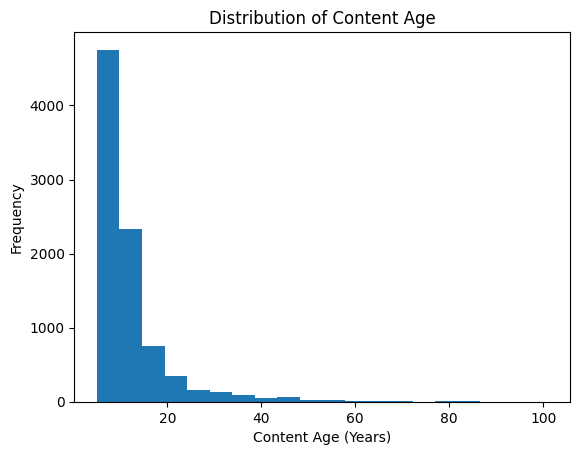

In [24]:

content_age = df ['content_age'].dropna()

plt.figure()
content_age.plot(kind='hist', bins=20)

plt.title("Distribution of Content Age")
plt.xlabel("Content Age (Years)")
plt.ylabel("Frequency")
plt.show()




the analysis show , netflix mainly focuses on the newly released contents and not intrested in buying the contets which are older 

### Bivariant Analysis

### 1. Top 10 Countries Contributing to Movies and TV Shows on Netflix

In [25]:
with open("encoding_mappings.json", "r") as f:
    mappings = json.load(f)

country_mapping = mappings["country_mapping"]

reverse_country_mapping = {v: k for k, v in country_mapping.items()}


df["country_decoded"] = df["country_encoded"].map(reverse_country_mapping)

df = df.dropna(subset=["country_decoded"])

df["country_split"] = df["country_decoded"].str.split(",")

df_exploded = df.explode("country_split")

df_exploded["country_split"] = df_exploded["country_split"].str.strip()

country_counts = df_exploded["country_split"].value_counts()

print("Top 10 Countries Producing Content:")
print(country_counts.head(10))


Top 10 Countries Producing Content:
country_split
United States     3687
India             1046
Unknown            831
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


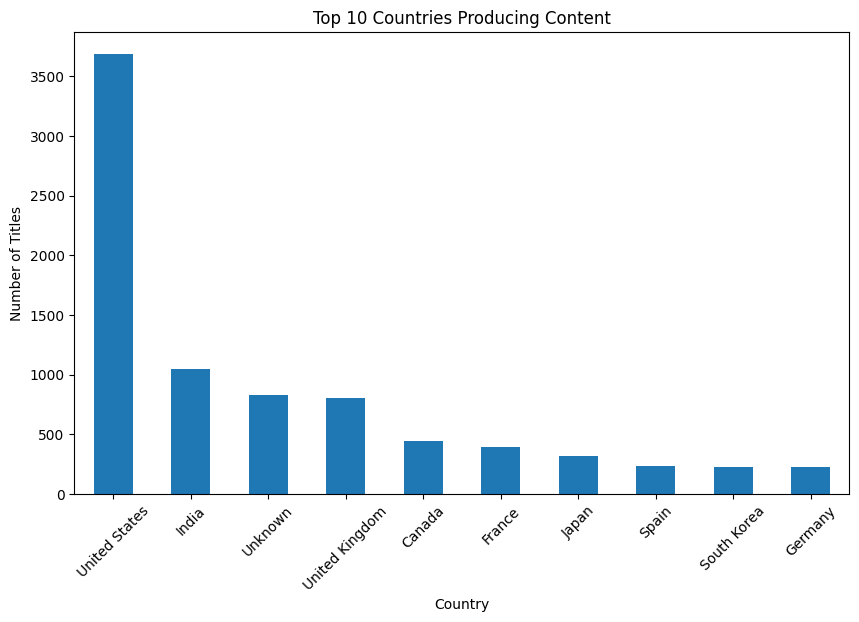

In [26]:
top_10 = country_counts.head(10)

plt.figure(figsize=(10,6))
top_10.plot(kind='bar')
plt.title("Top 10 Countries Producing Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

### 2. Top country producing movies vs tv series

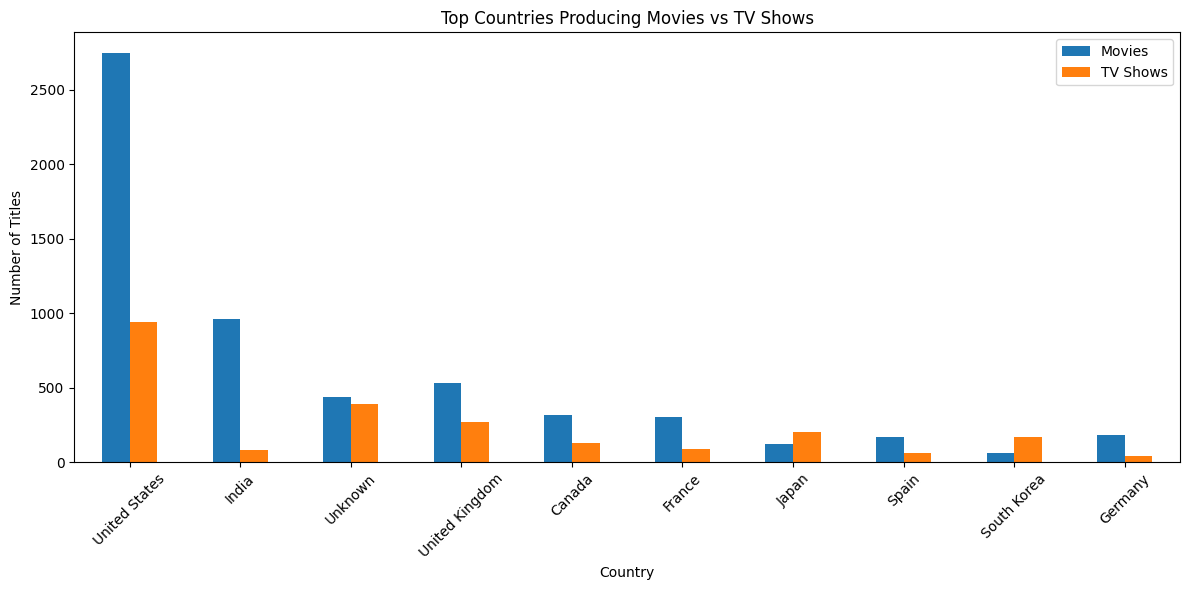

In [27]:
with open("encoding_mappings.json", "r") as f:
    mappings = json.load(f)

country_mapping = mappings["country_mapping"]

reverse_country_mapping = {v: k for k, v in country_mapping.items()}

df["country_decoded"] = df["country_encoded"].map(reverse_country_mapping)

df = df.dropna(subset=["country_decoded"])

df["country_split"] = df["country_decoded"].str.split(",")
df = df.explode("country_split")

df["country_split"] = df["country_split"].str.strip()

movies_df = df[df["is_movie"] == 1]
tv_df = df[df["is_movie"] == 0]

movie_counts = movies_df["country_split"].value_counts()
tv_counts = tv_df["country_split"].value_counts()

top_countries = (
    movie_counts.add(tv_counts, fill_value=0)
    .sort_values(ascending=False)
    .head(10)
    .index
)

comparison_df = pd.DataFrame({
    "Movies": movie_counts[top_countries],
    "TV Shows": tv_counts[top_countries]
}).fillna(0)

# Plot grouped bar chart
comparison_df.plot(kind="bar", figsize=(12,6))

plt.title("Top Countries Producing Movies vs TV Shows")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### 3. Country and genres

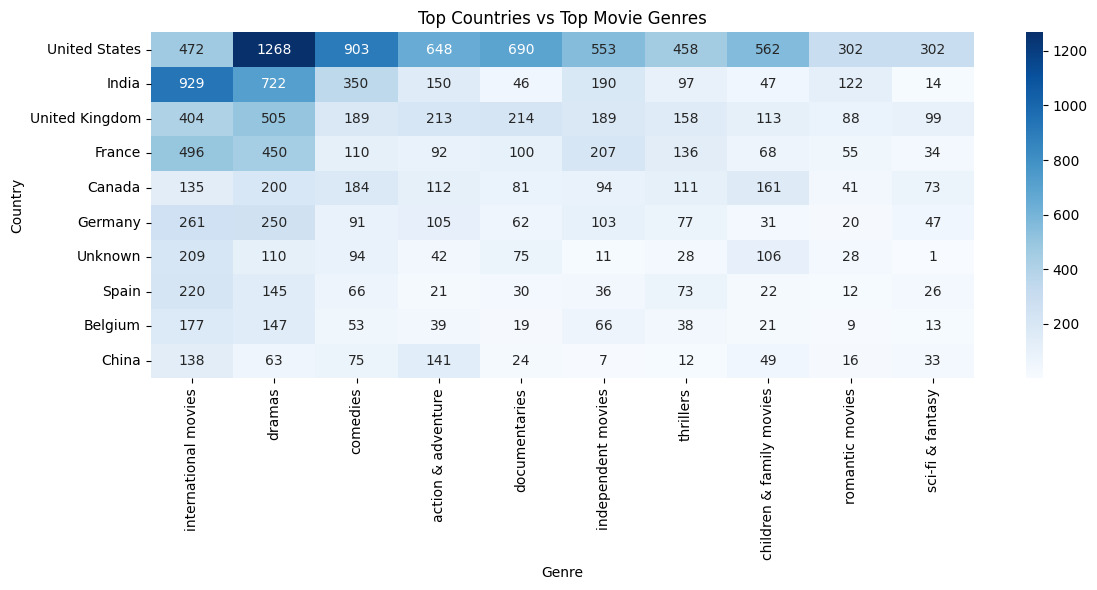

In [28]:
non_genre_cols = [
    'show_id','type','title','director','cast','country',
    'date_added','release_year','rating','rating_encoded',
    'duration','description','is_movie',
    'year_added','country_encoded','duration_int',
    'content_age','month_added'
]

# Detect genre columns safely
genre_cols = [col for col in df.columns if col not in non_genre_cols]

# Keep only numeric genre columns (safety check)
genre_cols = [col for col in genre_cols if pd.api.types.is_numeric_dtype(df[col])]

# Load country mapping
with open("encoding_mappings.json", "r") as f:
    mappings = json.load(f)

reverse_country_mapping = {v: k for k, v in mappings["country_mapping"].items()}

# Decode country
df["country_decoded"] = df["country_encoded"].map(reverse_country_mapping)

# Split multiple countries
df["country_split"] = df["country_decoded"].str.split(",")
df = df.explode("country_split")
df["country_split"] = df["country_split"].str.strip()

# Filter Movies only
movies_df = df[df["is_movie"] == 1]

# Top 10 Genres
top_genres = (
    movies_df[genre_cols]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Country vs Genre matrix
country_genre_matrix = (
    movies_df
    .groupby("country_split")[top_genres]
    .sum()
)

# Top 10 Countries
top_countries = (
    country_genre_matrix
    .sum(axis=1)
    .sort_values(ascending=False)
    .head(10)
    .index
)

country_genre_matrix = country_genre_matrix.loc[top_countries]

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(country_genre_matrix, annot=True, fmt=".0f", cmap="Blues")
plt.title("Top Countries vs Top Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

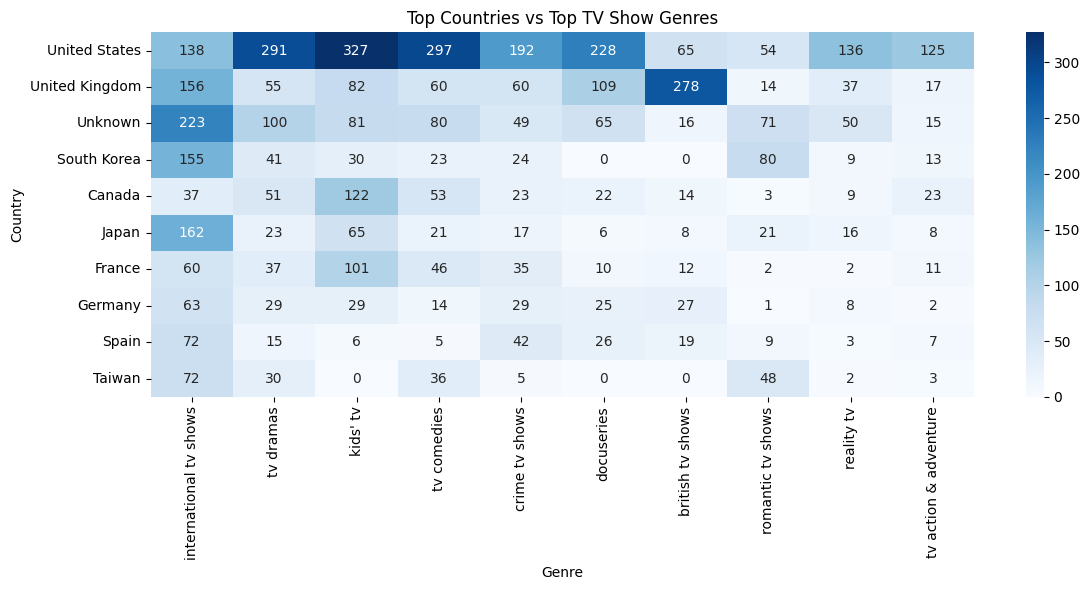

In [29]:
# Filter Movies only
movies_df = df[df["is_movie"] == 0]

# Top 10 Genres
top_genres = (
    movies_df[genre_cols]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Country vs Genre matrix
country_genre_matrix = (
    movies_df
    .groupby("country_split")[top_genres]
    .sum()
)

# Top 10 Countries
top_countries = (
    country_genre_matrix
    .sum(axis=1)
    .sort_values(ascending=False)
    .head(10)
    .index
)

country_genre_matrix = country_genre_matrix.loc[top_countries]

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(country_genre_matrix, annot=True, fmt=".0f", cmap="Blues")
plt.title("Top Countries vs Top TV Show Genres")
plt.xlabel("Genre")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

### 4. Directors contribution in Netflix

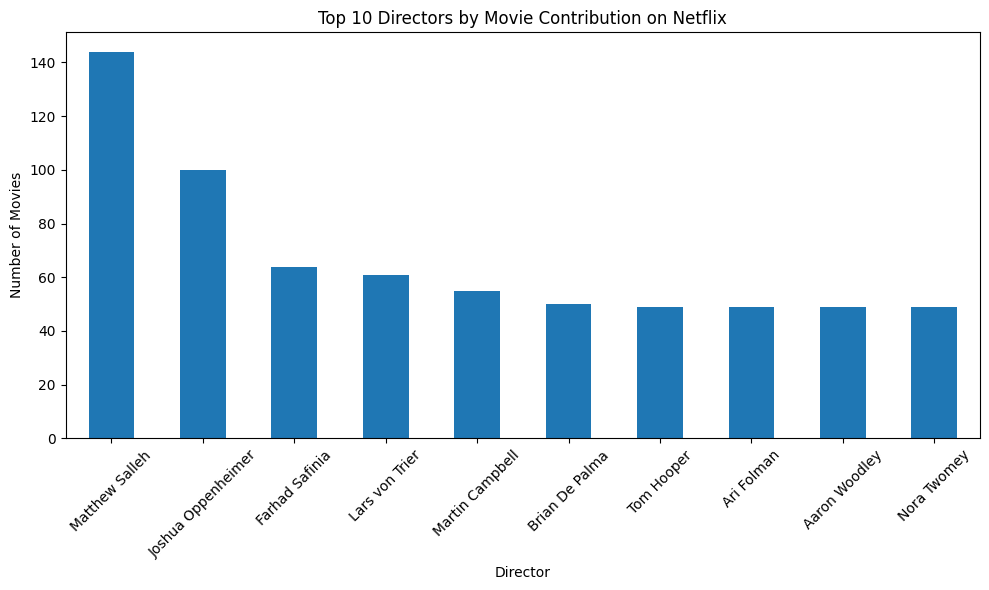

In [30]:
# Remove Unknown directors
df = df[df["director"] != "Unknown"]

#  Movies Director Analysis

movies_df = df[df["is_movie"] == 1]

top_movie_directors = (
    movies_df["director"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))
top_movie_directors.plot(kind="bar")
plt.title("Top 10 Directors by Movie Contribution on Netflix")
plt.xlabel("Director")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




### 5. Directors and genre

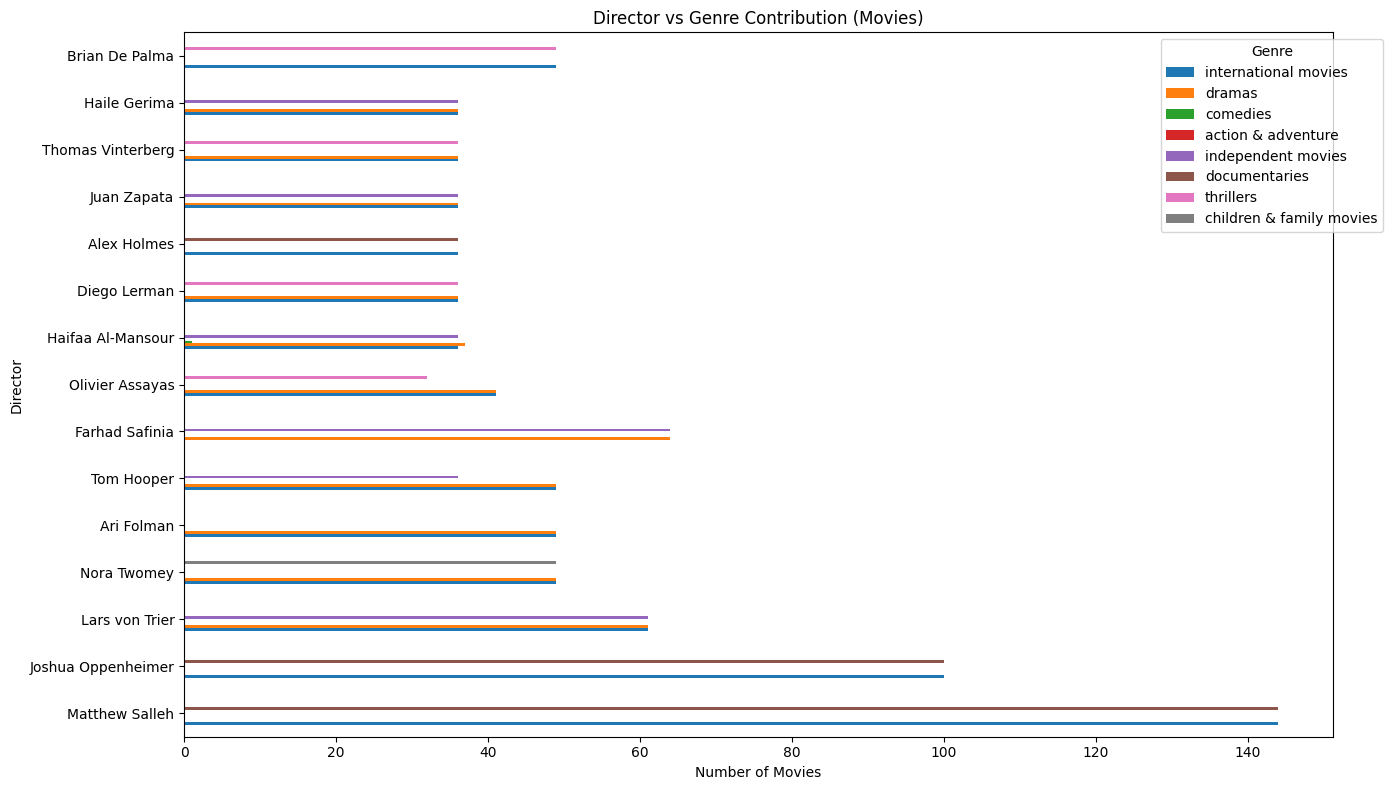

In [31]:
# Detect genre columns
genre_cols = [col for col in df.columns if col not in non_genre_cols]
genre_cols = [col for col in genre_cols if pd.api.types.is_numeric_dtype(df[col])]

# Remove Unknown
df = df[df["director"] != "Unknown"]

# Filter Movies
movies_df = df[df["is_movie"] == 1]

# Director vs Genre matrix
director_genre_movies = (
    movies_df
    .groupby("director")[genre_cols]
    .sum()
)

# Select top 15 directors
top_directors = (
    director_genre_movies.sum(axis=1)
    .sort_values(ascending=False)
    .head(15)
    .index
)

# Select top 8 genres
top_genres = (
    director_genre_movies.sum(axis=0)
    .sort_values(ascending=False)
    .head(8)
    .index
)

director_genre_movies = director_genre_movies.loc[top_directors, top_genres]
director_genre_movies = director_genre_movies.astype(int)

# Plot horizontal grouped bar
director_genre_movies.plot(kind="barh", figsize=(14,8))

plt.title("Director vs Genre Contribution (Movies)")
plt.xlabel("Number of Movies")
plt.ylabel("Director")
plt.legend(title="Genre", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

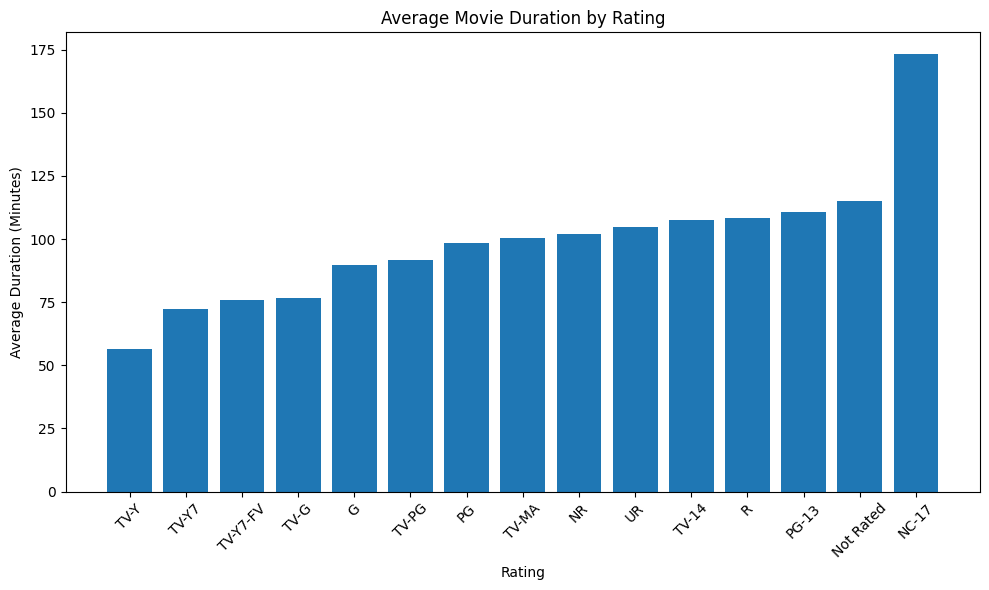

rating_decoded
TV-Y          56.386667
TV-Y7         72.437811
TV-Y7-FV      76.000000
TV-G          76.644330
G             89.779412
TV-PG         91.703529
PG            98.480460
TV-MA        100.319404
NR           101.868545
UR           104.666667
TV-14        107.516408
R            108.195205
PG-13        110.745006
Not Rated    115.000000
NC-17        173.200000
Name: duration_int, dtype: float64


In [ ]:
# Load rating mapping
with open("encoding_mappings.json", "r") as f:
    mappings = json.load(f)

# Detect rating mapping automatically
rating_mapping = None
for key in mappings.keys():
    if "rating" in key.lower():
        rating_mapping = mappings[key]
        break

# Reverse mapping
rating_mapping = {v: k for k, v in rating_mapping.items()}

# Decode rating
df["rating_decoded"] = df["rating_encoded"].map(rating_mapping)

# Remove missing
df = df.dropna(subset=["rating_decoded", "duration_int"])

# MOVIES
movies_df = df[df["is_movie"] == 1]

rating_duration_movies = (
    movies_df
    .groupby("rating_decoded")["duration_int"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))
plt.bar(rating_duration_movies.index, rating_duration_movies.values)

plt.title("Average Movie Duration by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Duration (Minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(rating_duration_movies)

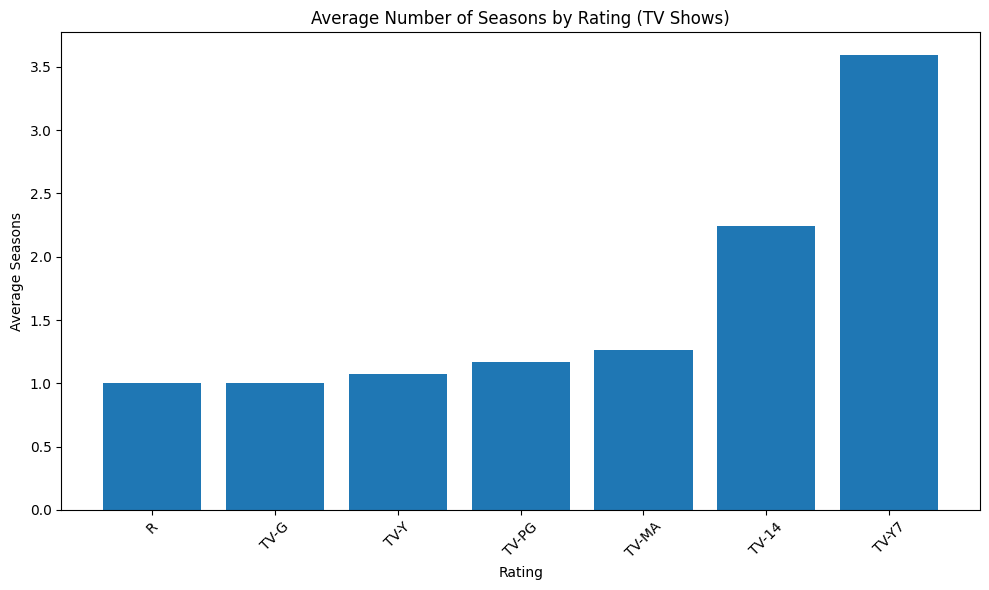

rating_decoded
R        1.000000
TV-G     1.000000
TV-Y     1.076923
TV-PG    1.170455
TV-MA    1.259887
TV-14    2.242424
TV-Y7    3.592593
Name: duration_int, dtype: float64


In [ ]:

# TV SHOWS
tv_df = df[df["is_movie"] == 0]

rating_duration_tv = (
    tv_df
    .groupby("rating_decoded")["duration_int"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))
plt.bar(rating_duration_tv.index, rating_duration_tv.values)

plt.title("Average Number of Seasons by Rating (TV Shows)")
plt.xlabel("Rating")
plt.ylabel("Average Seasons")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(rating_duration_tv)